# Evaluación final del modelo — Reconocimiento de señales de tránsito

Este notebook evalúa el modelo entrenado sobre el set de **test** (no visto durante el entrenamiento ni usado para early stopping), que es la métrica que corresponde reportar como resultado final.

## 1. Instalar dependencias

In [13]:
!pip install ultralytics -q

'C:\Program Files\Python311\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


## 2. Cargar los pesos del modelo (desde el repo)

In [ ]:
import os

# Ruta relativa: funciona para cualquiera que clone el repo y corra el notebook desde su raiz.
WEIGHTS_PATH = "modelo_final/best.pt"

assert os.path.exists(WEIGHTS_PATH), f"No se encontro {WEIGHTS_PATH}"
print("Pesos encontrados en:", WEIGHTS_PATH)


Pesos encontrados en: C:\Users\tatic\ドキュメント\MAESTRIA 2025 - FIUNA\5TO TRIMESTRE\Robotica\sign_traffic_recognition\modelo_final\best.pt


## 3. Cargar el dataset (desde el repo)

In [ ]:
import zipfile

# Ruta relativa: funciona para cualquiera que clone el repo y corra el notebook desde su raiz.
ZIP_PATH_ = "dataset/sign_recognition_picarx.yolov8.zip"
DATASET_DIR = "dataset_extraido"

if not os.path.exists(DATASET_DIR):
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATASET_DIR)

print("Dataset cargado desde:", ZIP_PATH)
print("Extraido en:", DATASET_DIR)


Dataset cargado desde: C:\Users\tatic\ドキュメント\MAESTRIA 2025 - FIUNA\5TO TRIMESTRE\Robotica\sign_traffic_recognition\dataset\signal_recognition_picarx.yolov8.zip
Extraido en: dataset_extraido


## 4. Cargar el modelo entrenado

In [16]:
from ultralytics import YOLO

model = YOLO(WEIGHTS_PATH)
print(model.names)

{0: 'avance', 1: 'ceder', 2: 'contramano', 3: 'derecha', 4: 'izquierda', 5: 'pare', 6: 'peaton', 7: 'peligro', 8: 'vel20', 9: 'vel30'}


## 5. Evaluación en el set de TEST
Por defecto `model.val()` evalúa sobre el split `val`. Para la evaluación **final** hay que forzarlo a usar `test`, que el modelo nunca vio ni para entrenar ni para decidir cuándo parar (`patience`).

In [17]:
metrics = model.val(
    data=f"{DATASET_DIR}/data.yaml",
    split="test",
    imgsz=640,
    plots=True,
)

print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision (promedio): {metrics.box.mp:.4f}")
print(f"Recall (promedio):    {metrics.box.mr:.4f}")

Ultralytics 8.4.171  Python-3.11.1 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 157.661.8 MB/s, size: 17.5 KB)
val: Scanning C:\Users\tatic\ドキュメント\MAESTRIA 2025 - FIUNA\5TO TRIMESTRE\Robotica\sign_traffic_recognition\notebooks\dataset_extraido\test\labels... 87 images, 0 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 87/87 945.4it/s 0.1s
val: C:\Users\tatic\\MAESTRIA 2025 - FIUNA\5TO TRIMESTRE\Robotica\sign_traffic_recognition\notebooks\dataset_extraido\test\images\photo_2026-09-17-17-12-40_jpg.rf.418747bc7f50638485545d338a8eae6b.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: C:\Users\tatic\\MAESTRIA 2025 - FIUNA\5TO TRIMESTRE\Robotica\sign_traffic_recognition\notebooks\dataset_extraido\test\images\photo_2026-09-17-17-19-08_jpg.rf.00ce613370ddcf7dd2582fe574043bea.jpg: ignoring corrupt image/label: labels mix 

## 6. Métricas por clase

In [18]:
import pandas as pd

class_names = model.names
rows = []
for i, name in class_names.items():
    rows.append({
        "clase": name,
        "precision": metrics.box.p[i],
        "recall": metrics.box.r[i],
        "mAP50": metrics.box.ap50[i],
        "mAP50-95": metrics.box.ap[i],
    })

df_clases = pd.DataFrame(rows).sort_values("mAP50", ascending=True)
df_clases

,clase,precision,recall,mAP50,mAP50-95
3,derecha,0.991267,0.888889,0.885,0.823125
1,ceder,0.804091,0.913891,0.975,0.933429
0,avance,0.993794,1.000000,0.995,0.923256
2,contramano,0.994418,1.000000,0.995,0.965000
4,izquierda,0.994607,1.000000,0.995,0.900923
5,pare,0.993418,1.000000,0.995,0.894549
6,peaton,0.991194,1.000000,0.995,0.905376
7,peligro,0.993707,1.000000,0.995,0.893736
8,vel20,0.981681,1.000000,0.995,0.921042
9,vel30,0.992269,1.000000,0.995,0.892429


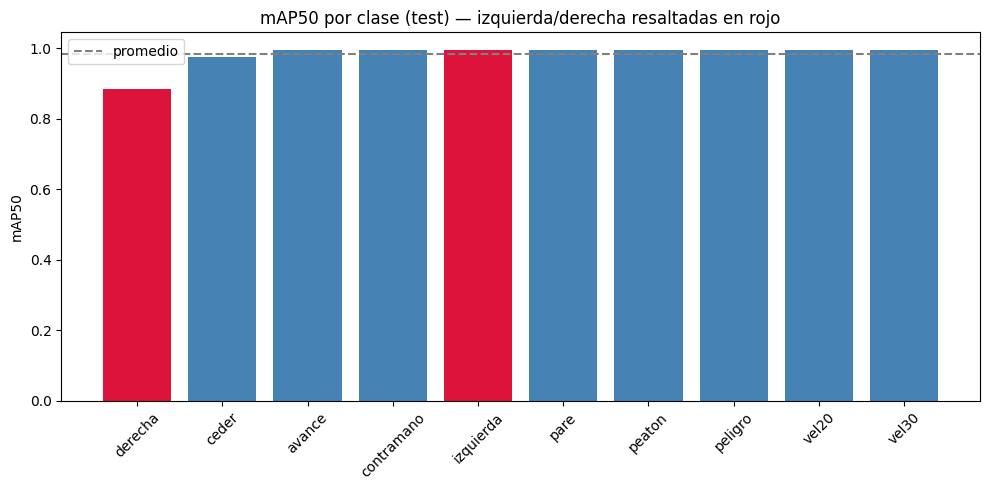

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
colores = ['crimson' if c in ('izquierda', 'derecha') else 'steelblue' for c in df_clases['clase']]
plt.bar(df_clases['clase'], df_clases['mAP50'], color=colores)
plt.title("mAP50 por clase (test) — izquierda/derecha resaltadas en rojo")
plt.ylabel("mAP50")
plt.xticks(rotation=45)
plt.axhline(df_clases['mAP50'].mean(), color='gray', linestyle='--', label='promedio')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Matriz de confusión
Generada automáticamente por `model.val()` (con `plots=True`) dentro de `runs/detect/val*/`. La mostramos acá directamente.

Carpeta de resultados: runs/detect\val


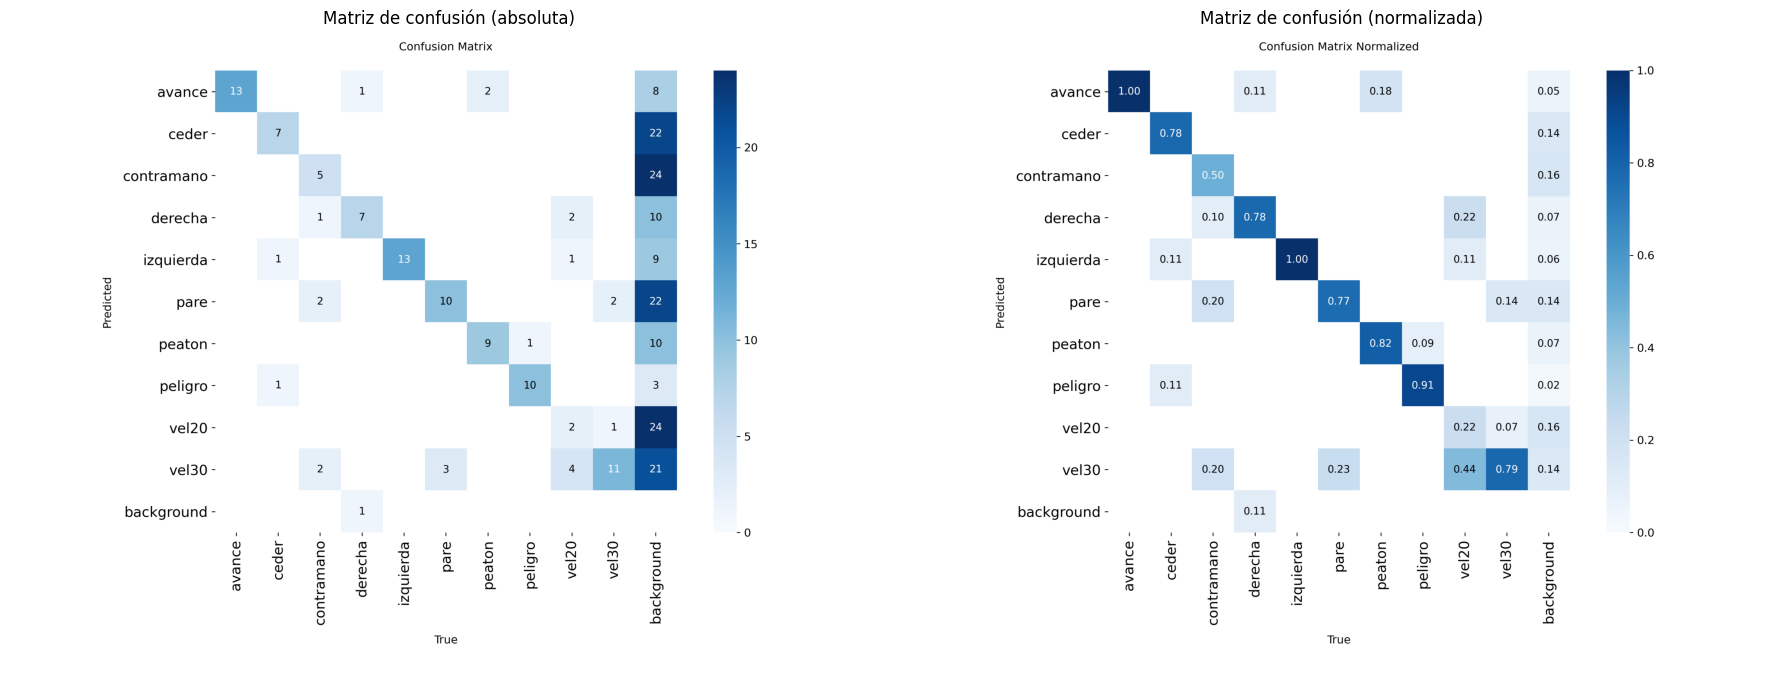

In [20]:
import glob
from PIL import Image

run_dir = sorted(glob.glob('runs/detect/val*'), key=lambda p: p)[-1]
print('Carpeta de resultados:', run_dir)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(Image.open(f'{run_dir}/confusion_matrix.png'))
axes[0].axis('off')
axes[0].set_title('Matriz de confusión (absoluta)')
axes[1].imshow(Image.open(f'{run_dir}/confusion_matrix_normalized.png'))
axes[1].axis('off')
axes[1].set_title('Matriz de confusión (normalizada)')
plt.tight_layout()
plt.show()

## 8. Velocidad de inferencia
Referencia de cuántas imágenes por segundo procesa el modelo — relevante para saber si va a poder correr en tiempo real en la Raspberry Pi (la medición acá es en la GPU/CPU de Colab, no en la Pi, pero sirve como comparación relativa entre modelos).

In [22]:
import time
import numpy as np

dummy = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

# warm-up
for _ in range(5):
    model.predict(dummy, imgsz=640, verbose=False)

N = 50
t0 = time.time()
for _ in range(N):
    model.predict(dummy, imgsz=640, verbose=False)
t1 = time.time()

ms_por_imagen = (t1 - t0) / N * 1000
print(f"Tiempo promedio por imagen: {ms_por_imagen:.1f} ms")
print(f"FPS estimados (en este entorno): {1000/ms_por_imagen:.1f}")

Tiempo promedio por imagen: 12.2 ms
FPS estimados (en este entorno): 81.8


## 9. Inspección visual: predicciones vs. etiquetas reales
Grid de imágenes de test con las cajas predichas, para una revisión cualitativa rápida.

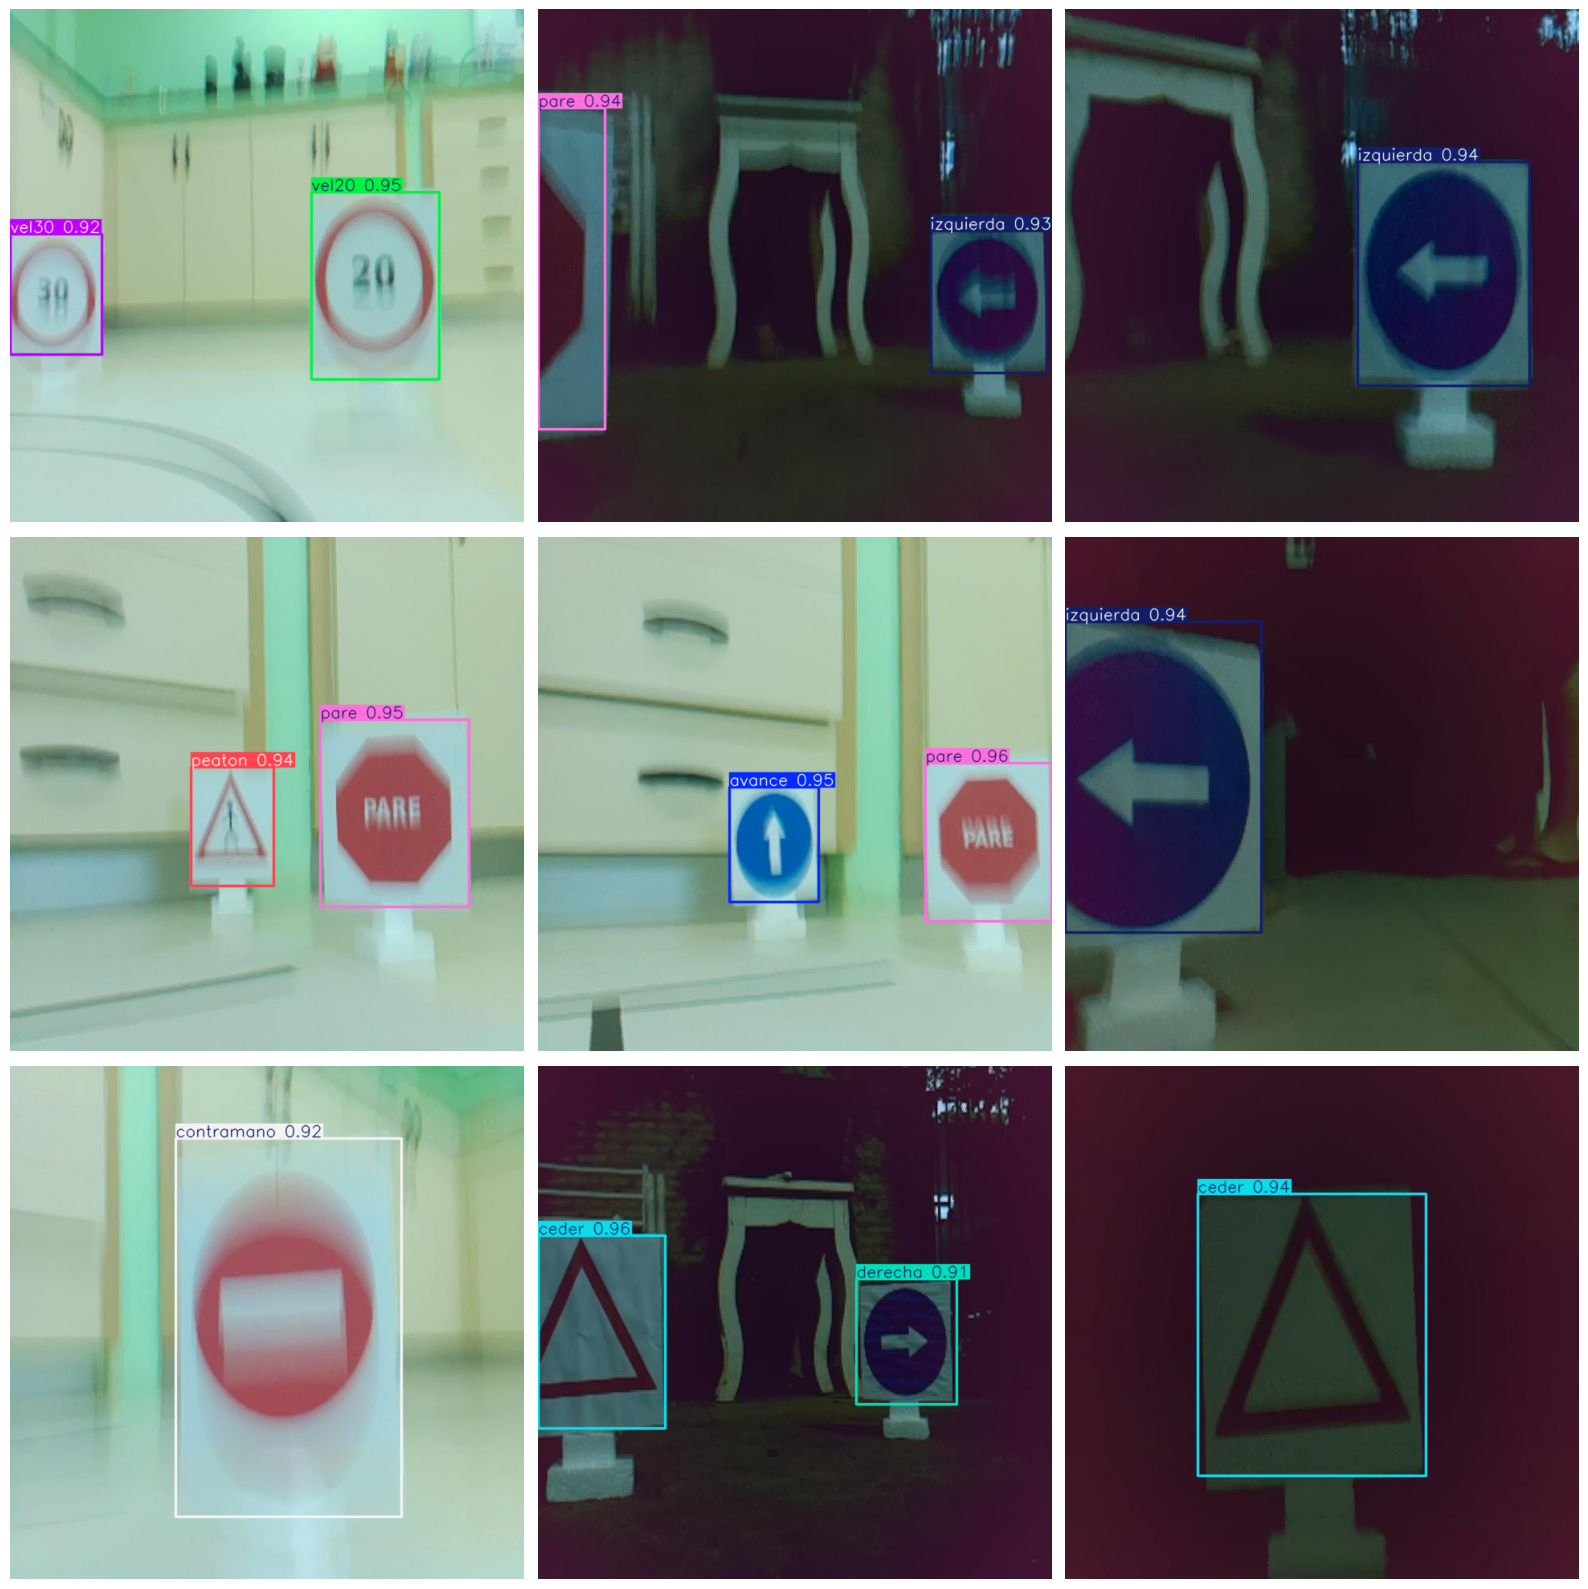

In [23]:
import random
import cv2

test_img_dir = f"{DATASET_DIR}/test/images"
test_imgs = os.listdir(test_img_dir)
sample = random.sample(test_imgs, min(9, len(test_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
for ax, fname in zip(axes.flatten(), sample):
    img_path = os.path.join(test_img_dir, fname)
    res = model.predict(img_path, imgsz=640, conf=0.5, verbose=False)[0]
    annotated = res.plot()
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.show()